# Maths in Neural Networks

**Introduction**

I’ve tried several times to understand the mathematics behind neural networks and how they are trained. Each time, I manage to grasp parts of it, but after a few weeks much of that understanding fades. There are several reasons for this:

* The equations and notation can be quite complex.
* Different books and videos often use different symbols and formulations.
* I struggled to find an effective way to study the material — whether to simply read, work through equations by hand, or jump straight into coding examples.

**Goal**

The main goal of this project is to share the parts I personally found difficult to grasp — the common "gotchas".
Rather than attempting yet another comprehensive explanation, I’ll focus on highlighting the tricky aspects, since there are already many excellent resources that cover the full theory.

In [107]:
%matplotlib inline

In [108]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import tensorflow as tf
from IPython.display import Image, Markdown
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

## Function Vectorization

Key Ideas

* Most standard functions are written to work with single values. In software engineering, if we want them to process many values, we usually add a loop inside the function.
* In machine learning, functions often appear to operate on a single value, but in practice they are applied to entire vectors or matrices of values at once.

Two examples to showcase the ideas above.

In [109]:
# Most NumPy functions (such as `np.exp`) are already vectorized, meaning they automatically work with arrays without requiring loops.

def sigmoid(z):
    return 1. / (1. + np.exp(-z))

In [110]:
# We can convert a scalar function so it works on arrays using `np.vectorize()`. Rarely needed in practice.

def square(x):
    return x ** 2


square = np.vectorize(square)
arr = np.array([1, 2, 3, 4])
square(arr)

array([ 1,  4,  9, 16])

Most textbook equations follow the same pattern—you don’t immediately know what kind of object a symbol represents or what shape it has. I’ve found it helpful to write down the shapes (e.g. by using draw.io). Example below is from Géron [3].

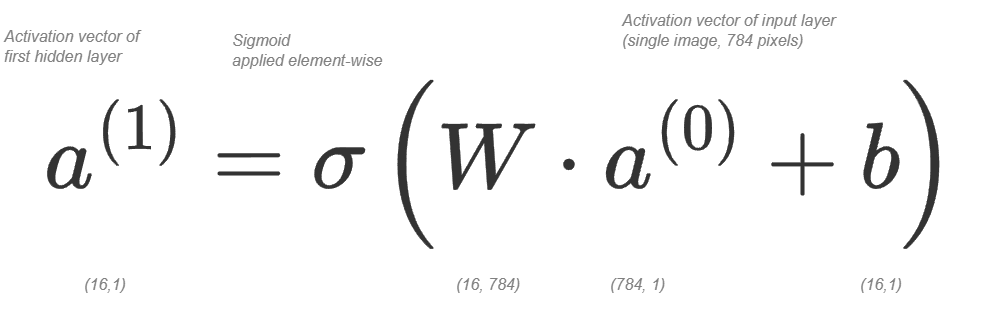

In [111]:
Image(filename='images/02.png', width=800)

## Neurons Types

Neural network explanations often mention several foundational neuron models: TLU, Perceptron, and Adaline. I struggled to understand the difference between them.

All of them are single‑unit (or single‑layer) abstractions inspired by biological neurons, computing a weighted sum of inputs.

**Historical progression**

- The TLU (1943) introduced the basic idea but had no learning — weights were set by hand.
- The Perceptron (1958) added an automatic learning rule.
- Adaline (1960) refined it so that weight updates use the continuous linear output rather than the thresholded prediction.

**Output behavior**

- TLU: binary output
- Perceptron: binary output
- Adaline: uses a continuous output during training for weight updates, but still applies a threshold to produce a binary prediction

**Learning characteristics**

- TLU: no learning mechanism — weights were manually configured
- Perceptron: updates weights based on binary classification errors
- Adaline: updates weights based on continuous error values, enabling smoother and more efficient optimization

**Error handling**

The Perceptron updates only when it misclassifies, whereas Adaline measures how far off the continuous prediction is, allowing more precise weight adjustments.

## Vectors as Matrices

In ML, vectors are often treated as matrices so that linear algebra operations like matrix multiplication work consistently. Although mathematically a vector of size n can be written simply as `(n,)`, many ML implementations treat it as a column matrix of shape `(n,1)`.

In [112]:
W = np.arange(1, 10).reshape((3, 3))
x = np.array([2, -1, 4])

W, x, W @ x

(array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]),
 array([ 2, -1,  4]),
 array([12, 27, 42]))

In [113]:
W = np.arange(1, 10).reshape((3, 3))
x = np.array([2, -1, 4]).reshape(-1, 1)

W, x, W @ x

(array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]),
 array([[ 2],
        [-1],
        [ 4]]),
 array([[12],
        [27],
        [42]]))

## Layer Activations Formulas

Calculating the activation of a layer based on the preceding layer can be confusing, especially since different authors use different conventions for matrix orientation.

To clear this up, I have compared the equations used by Géron [1] and 3Blue1Brown [3]. To make these abstract formulas more concrete, I used a dataset - the classical [MNIST](https://en.wikipedia.org/wiki/MNIST_database). First equation to calculate the hidden layer activations is Géron's [1] (it contains all training examples), next comes 3Blue1Brown [3] and is for a single instance. At a glance:
- Géron [1]: Uses a vectorized approach designed for the entire training set at once. Mini-batch can also be used.
- 3Blue1Brown [3]: Focuses on the intuition of a single training instance.

Pay close attention to the symbols and the order of multiplication. The comments on the diagrams below provide a deeper dive into how these two notations differ from one another.

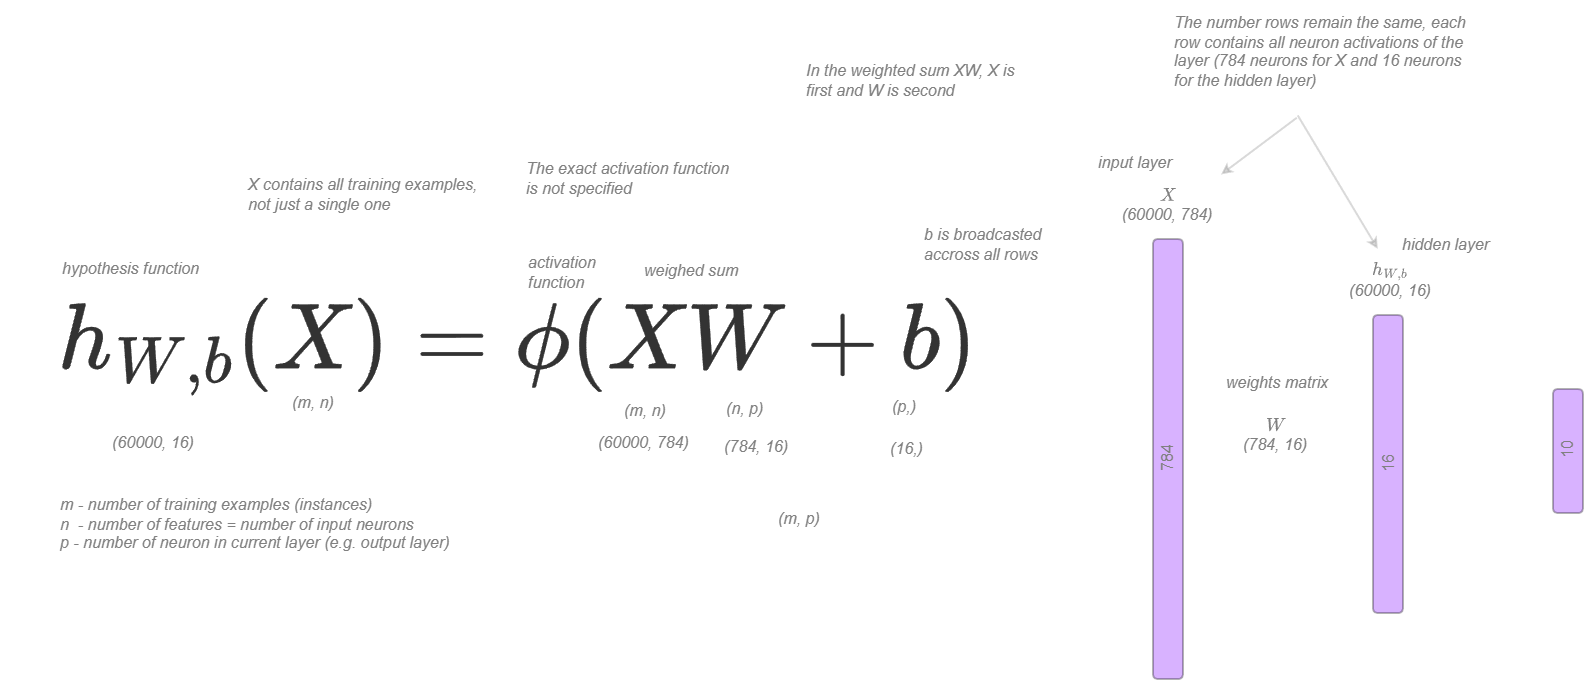

In [114]:
Image(filename='images/01.png', width=1200)

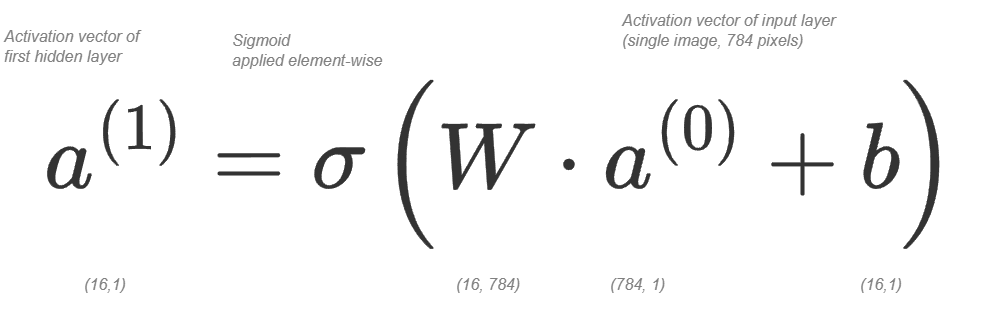

In [115]:
Image(filename='images/02.png', width=800)

## Compute Derivatives

How do computers compute derivatives, which are needed to update neural network parameters?

Generally, there are four main approaches:

1. Manual: Deriving the derivative formula manually using calculus rules
2. Numerical: Approximating the derivative using the difference formula
3. Symbolic: Applying symbolic differentiation rules automatically, similar to manual calculus but performed by software
4. AutoDiff: Using Automatic Differentiation, with backpropagation being the version used in neural networks

Let's see an example:

$$y = \ln(x_1) + x_1 x_2 - \sin(x_2)$$

and we want $$\frac{\partial{y}}{\partial{x_1}} \text{ at } x_1 = 2, x_2 = 5$$

True derivative at those values is:
$$\frac{\partial{y}}{\partial{x_1}} = \frac{1}{x_1} + x_2 = \frac{1}{2} + 5 = 5.5$$

**Manual**

Differentiate term by term. We then use the derivative formula DIRECTLY in the code.

$$\frac{\partial}{\partial x_1}\bigl[\ln x_1\bigr] = \frac{1}{x_1}, \quad \frac{\partial}{\partial x_1}\bigl[x_1 x_2\bigr] = x_2, \quad \frac{\partial}{\partial x_1}\bigl[\sin x_2\bigr] = 0$$

$$\boxed{\frac{\partial y}{\partial x_1} = \frac{1}{x_1} + x_2}$$

In [116]:
def manual(x1, x2):
    return 1 / x1 + x2


manual(2.0, 5.0)

5.5

**Numerical**

$$\frac{\partial y}{\partial x_1} \approx \frac{f(x_1 + h,\ x_2) - f(x_1,\ x_2)}{h}$$

In [117]:
def f(x1, x2):
    return np.log(x1) + x1 * x2 - np.sin(x2)


def numerical(x1, x2, h=1e-5):
    return (f(x1 + h, x2) - f(x1, x2)) / h


numerical(2.0, 5.0)

np.float64(5.4999987499471095)

**Symbolic**

Manipulates the expression algebraically and returns an exact formula.

In [118]:
x1, x2 = sp.symbols('x1 x2')
f = sp.ln(x1) + x1 * x2 - sp.sin(x2)

df = sp.diff(f, x1)
print(df)
print(df.subs({x1: 2, x2: 5}))

x2 + 1/x1
11/2


**AutoDiff**

Many sources attempt to explain backpropagation, but even after going through several of them, I still struggled to fully grasp how the algorithm works.

Two resources proved especially helpful: the article in [4] and the code implementation in [5]. Given the complexity of the topic, I decided to break it down into separate sections (see next sections).

**Summary**

Finally, a brief summary of all four methods:
- Manual: 5.5 — exact, done by hand
- Numerical: 5.49999… — approximate, one call per parameter
- Symbolic: 11/2 = 5.5 — exact, but expression size explodes with depth
- AutoDiff: 5.5 — exact, all gradients in one backward pass

## AutoDiff On Paper: Forward Mode

I find it easier to grasp the core concept when concrete examples are used in the comments rather than abstract generalizations.

Let's look at this table from [4].

<img src="images/04.png" style="width: 800px;">


**Indexes**

- The indexes of the $v$'s carry meaning - negative to 0 are the inputs ($v_{-1}, v_{0}$), the rest are intermediate variables.

**Dot notation**

- The dot notation is always with respect to $x_1$.
- For example, $\dot{v_1}$ means $\frac{\partial v_1}{\partial x_1}$, $\dot{v_2}$ means $\frac{\partial v_2}{\partial x_1}$.


**Calculate $\dot{v}_1$**

$$
\dot{v}_1
= \frac{\partial v_1}{\partial x_1}
= \frac{\partial (\ln v_{-1})}{\partial x_1}
= \frac{\partial (\ln v_{-1})}{\partial v_{-1}} \frac{\partial v_{-1}}{\partial x_1}
= \frac{1}{v_{-1}} \dot{v}_{-1}
$$

We already know both values and can just substitute:
$$
v_{-1} = 2, \dot{v}_{-1} = 1
$$

$$
\dot{v}_1 = \frac{1}{2} \cdot 1 = \frac{1}{2}
$$


**Calculate $\dot{v}_2$**

$$
\dot{v}_2
= \frac{\partial v_2}{\partial x_1}
= \frac{\partial (v_{-1} \times v_0)}{\partial x_1}
= \frac{\partial v_{-1}}{\partial x_1} \cdot v_0 + v_{-1} \cdot \frac{\partial v_0}{\partial x_1}
= \dot{v}_{-1} \cdot v_0 + v_{-1} \cdot \dot{v}_0
$$

Again, we already know all four values and can just substitute:

$$
\dot{v}_{-1} = 1,\quad v_0 = 5,\quad v_{-1} = 2,\quad \dot{v}_0 = 0
$$

$$
\dot{v}_2 = 1 \cdot 5 + 2 \cdot 0 = 5
$$

**Seeds**

- We set $\dot{x}_1 = 1$ and $\dot{x}_2 = 0$, which is equivalent to asking "if I nudge $x_1$ by a tiny $\epsilon$ and hold $x_2$ fixed, how does each intermediate variable change?" So $x_2$ is treated as a constant with respect to this perturbation — its derivative is zero.
- If you wanted $\frac{\partial y}{\partial x_2}$ instead, you'd do a second forward pass with $\dot{x}_1 = 0, \dot{x}_2 = 1$, and all the terms would flip.


## AutoDiff On Paper: Reverse Mode

Reverse mode is what we use when training neural network. I do the same as above - comment the parts which were hard for me to grasp at first. Again, the image is from [4].

<img src="images/05.png" style="width: 800px;">

**Bar notation = Adjoint**

- The bar notation $\bar{v}_i$ denotes the adjoint of $v_i$, defined as $\bar{v}_i = \frac{\partial y}{\partial v_i}$ — how much the output $y$ changes when $v_i$ changes.
- Similar to before, the adjoint ALWAYS has $\partial y$ in the numerator (incorrectly mathematically said, but easiest to explain it this way): $\bar{v}_4 = \frac{\partial y}{\partial v_4}$, $\bar{v}_3 = \frac{\partial y}{\partial v_3}$

**Stages**

- Forward mode computes the primal and its tangent (the two columns with calculations) simultaneously as a pair at each step.
- Reverse mode operates in two stages: a forward pass that computes and stores all intermediate values, followed by a backward pass that uses them to calculate derivatives.

**Seed**

- We set $\bar{y} = \bar{v}_5 = 1$, meaning "a unit change in $y$ causes a unit change in $y$." This is the equivalent of setting $\dot{x}_1 = 1$ in forward mode — it seeds the sweep.
- A single reverse sweep gives us both $\frac{\partial y}{\partial x_1}$ and $\frac{\partial y}{\partial x_2}$ at once, unlike forward mode which requires one pass per input.

**Calculate $\bar{v}_4$**

$$
\bar{v}_4
= \frac{\partial y}{\partial v_4}
= \frac{\partial y}{\partial v_5} \cdot \frac{\partial v_5}{\partial v_4}
= \bar{v}_5 \cdot \frac{\partial (v_4 - v_3)}{\partial v_4}
= \bar{v}_5 \cdot 1
$$

We already know both values and can just substitute:

$$
\bar{v}_5 = 1
$$

$$
\bar{v}_4 = 1 \cdot 1 = 1
$$

**Calculate $\bar{v}_3$**

$$
\bar{v}_3
= \frac{\partial y}{\partial v_3}
= \frac{\partial y}{\partial v_5} \cdot \frac{\partial v_5}{\partial v_3}
= \bar{v}_5 \cdot \frac{\partial (v_4 - v_3)}{\partial v_3}
= \bar{v}_5 \cdot (-1)
$$

We already know both values and can just substitute:

$$
\bar{v}_5 = 1
$$

$$
\bar{v}_3 = 1 \cdot (-1) = -1
$$

The $-1$ comes from the fact that $v_3$ appears with a minus sign in $v_5 = v_4 - v_3$, so increasing $v_3$ decreases $y$.

**Calculate $\bar{v}_0$ (contribution from $v_3$)**

<img src="images/06.png" style="width: 400px;">


$$
\bar{v}_0
= \frac{\partial y}{\partial v_0}
= \frac{\partial y}{\partial v_3} \cdot \frac{\partial v_3}{\partial v_0}
= \bar{v}_3 \cdot \frac{\partial (\sin v_0)}{\partial v_0}
= \bar{v}_3 \cdot \cos v_0
$$

We already know both values and can just substitute:

$$
\bar{v}_3 = -1, \quad v_0 = 5
$$

$$
\bar{v}_0 = -1 \cdot \cos(5) = -1 \cdot 0.2837 = -0.2837
$$

Note this is only the contribution from $v_3$. Since $v_0 = x_2$ also feeds into $v_2 = v_{-1} \times v_0$, a second contribution $\bar{v}_2 \cdot v_{-1}$ will be accumulated into $\bar{v}_0$ in the next step — matching the `+=` in the code.


## Autodiff In Code: Reverse Mode

First, I implement the calculations above.

Notes:

- Basic local derivatives are handled **symbolically** and embedded directly into the code. For example, when computing $\bar{v}_0 = \bar{v}_3 \cdot \cos(v_0)$, the derivative of $\sin$ is symbolically represented as $\cos$.
- Thus, symbolic differentiation serves as a building block within the broader AD process.

This is known as a computational graph, although it didn’t do much to clarify the underlying idea for me.
```mermaid
graph LR
    x1(["x₁"])
    x2(["x₂"])

    v1["v₁ = ln(x₁)"]
    v2["v₂ = x₁ · x₂"]
    v3["v₃ = v₁ + v₂"]
    v4["v₄ = sin(x₂)"]
    y(["y = v₃ − v₄"])

    x1 --> v1
    x1 --> v2
    x2 --> v2
    x2 --> v4
    v1 --> v3
    v2 --> v3
    v3 --> y
    v4 --> y
```

Showing the image again to easily compare with the code.
<img src="images/05.png" style="width: 800px;">

In [119]:
def backward(x1, x2):
    # Forward pass — using paper's variable names
    v_minus1 = x1
    v0 = x2
    v1 = math.log(v_minus1)
    v2 = v_minus1 * v0
    v3 = math.sin(v0)
    v4 = v1 + v2
    v5 = v4 - v3
    y = v5

    # Backward pass — adjoints (v_bar = dy/dv)
    v5_bar = 1.0

    # v5 = v4 - v3
    v4_bar = v5_bar * 1.0
    v3_bar = v5_bar * -1.0

    # v4 = v1 + v2
    v1_bar = v4_bar * 1.0
    v2_bar = v4_bar * 1.0

    # v3 = sin(v0)
    v0_bar = v3_bar * math.cos(v0)

    # v2 = v_minus1 * v0,  accumulate into v_minus1_bar and v0_bar
    v_minus1_bar = v2_bar * v0
    v0_bar += v2_bar * v_minus1

    # v1 = ln(v_minus1),  accumulate into v_minus1_bar
    v_minus1_bar += v1_bar * (1 / v_minus1)

    # Inputs
    x1_bar = v_minus1_bar
    x2_bar = v0_bar

    return x1_bar, x2_bar


x1, x2 = 2.0, 5.0
dy_dx1, dy_dx2 = backward(x1, x2)

print(f"dy/dx1 (autodiff) = {dy_dx1:.4f}")
print(f"dy/dx1 (analytic) = {1 / x1 + x2:.4f}")

dy/dx1 (autodiff) = 5.5000
dy/dx1 (analytic) = 5.5000


I also found it helpful to step through the code from Raschka’s book [2], which is [publicly available on GitHub [5]](https://github.com/rasbt/machine-learning-book/blob/main/ch11/neuralnet.py).

For debugging, using a standalone Python file with the PyCharm debugger worked best. Debugging directly in a notebook requires jumping between multiple cells, whereas PyCharm displays all variable values in one place, making it much easier to inspect shapes and intermediate results.

I also used draw.io to annotate the process. It’s a quick and flexible way to add free‑form comments to diagrams and code snippets.

A small excerpt is shown below; the full draw.io diagram is included in the project files.

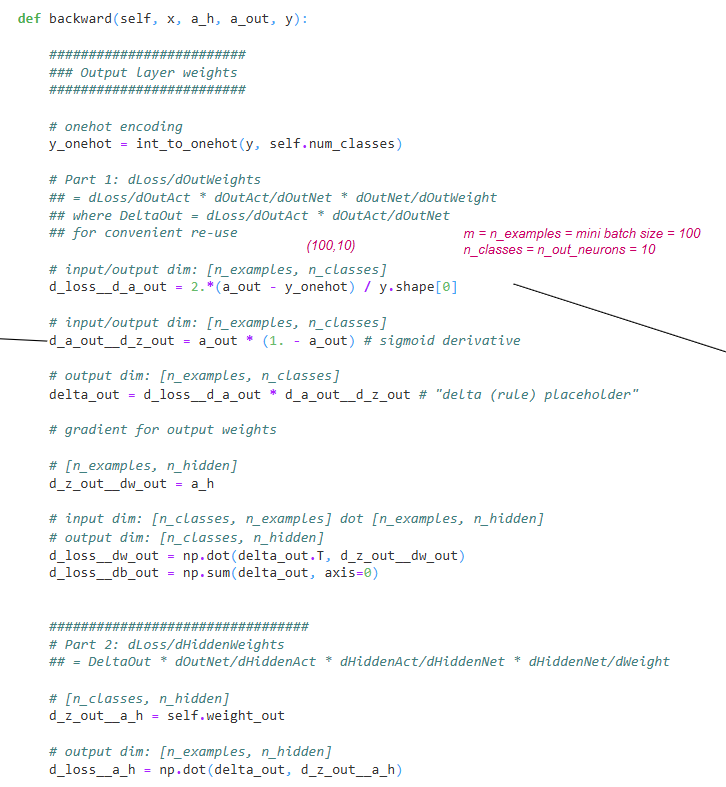

In [120]:
Image(filename='images/03.png', width=800)

## Autodiff In Code: Tensorflow

While reading [1], I learned how TensorFlow computes gradients using autodiff and adapted the book’s example (available in the public repo [8]) for this notebook.

In [121]:
def f(w1, w2):
    return 3 * w1 ** 2 + 2 * w1 * w2


def df_dw_manual(w1, w2):
    """Return a tuple with the values of the two partial derivatives (df_dw1, df_dw2)."""
    return (6 * w1 + 2 * w2, 2 * w1)


def df_dw_numeric(w1, w2, eps=1e-6):
    return (
        (f(w1 + eps, w2) - f(w1, w2)) / eps,
        (f(w1, w2 + eps) - f(w1, w2)) / eps,
    )


def df_dw_autodiff(w1, w2):
    w1_tf, w2_tf = tf.Variable(w1), tf.Variable(w2)
    with tf.GradientTape() as tape:
        z = f(w1_tf, w2_tf)

    return tape.gradient(z, [w1_tf, w2_tf])


w1, w2 = 5., 3.
display(Markdown(r"( $\frac{\partial f}{\partial w1}$, $\frac{\partial f}{\partial w2}$ )"))
print("Manual:", df_dw_manual(w1, w2))
print("Numeric:", df_dw_numeric(w1, w2))
print("Autodiff:", df_dw_autodiff(w1, w2))


( $\frac{\partial f}{\partial w1}$, $\frac{\partial f}{\partial w2}$ )

Manual: (36.0, 10.0)
Numeric: (36.000003007075065, 10.000000003174137)
Autodiff: [<tf.Tensor: shape=(), dtype=float32, numpy=36.0>, <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]


## Backprop

Backpropagation is essentially reverse‑mode autodiff tailored to the layered structure of neural networks.

**!** It took me a while to realize that we need the partial derivative for EVERY single weight and bias in the network, from the final output layer all the way back to the very first inputs. We update ALL at once, we need to calculate all derivatives.

The following example, generated by Claude, demonstrates backpropagation in a network with a 10-20-1 architecture (number of neurons in the intput-hidden-output layers). I’m focusing on the high-level intuition rather than the granular math, as frameworks like TensorFlow and PyTorch handle the heavy lifting anyway.

**Setup**

A simple feedforward network with:
- Input $\mathbf{x} \in \mathbb{R}^{10}$, weights $W^{(1)} \in \mathbb{R}^{20 \times 10}$, bias $\mathbf{b}^{(1)} \in \mathbb{R}^{20}$
- Hidden layer with sigmoid activation
- Output weights $\mathbf{w}^{(2)} \in \mathbb{R}^{20}$, bias $b^{(2)} \in \mathbb{R}$, scalar output $y \in \mathbb{R}$
- Loss $\mathcal{L} = \frac{1}{2}(y - t)^2$ where $t$ is the target

**Intermediate variables (forward pass)**

$$
v_1 = W^{(1)}\mathbf{x} + \mathbf{b}^{(1)} \in \mathbb{R}^{20} \qquad \text{(pre-activation, hidden)}
$$
$$
v_2 = \sigma(v_1) \in \mathbb{R}^{20} \qquad \text{(post-activation, hidden)}
$$
$$
v_3 = \mathbf{w}^{(2)\top} v_2 + b^{(2)} \in \mathbb{R} \qquad \text{(pre-activation, output)}
$$
$$
v_4 = v_3 \in \mathbb{R} \qquad \text{(output, no activation)}
$$
$$
\mathcal{L} = \tfrac{1}{2}(v_4 - t)^2
$$

**Seed**

$$
\bar{\mathcal{L}} = 1
$$

**Calculate $\bar{v}_4$**

$$
\bar{v}_4
= \frac{\partial \mathcal{L}}{\partial v_4}
= \frac{\partial \mathcal{L}}{\partial \mathcal{L}} \cdot \frac{\partial \mathcal{L}}{\partial v_4}
= \bar{\mathcal{L}} \cdot \frac{\partial}{\partial v_4}\tfrac{1}{2}(v_4 - t)^2
= \bar{\mathcal{L}} \cdot (v_4 - t)
$$

We already know both values and can just substitute:

$$
\bar{\mathcal{L}} = 1, \quad v_4 - t = \text{(prediction error)}
$$

$$
\bar{v}_4 = 1 \cdot (v_4 - t) = (v_4 - t)
$$

**Calculate $\bar{v}_3$**

$$
\bar{v}_3
= \frac{\partial \mathcal{L}}{\partial v_3}
= \frac{\partial \mathcal{L}}{\partial v_4} \cdot \frac{\partial v_4}{\partial v_3}
= \bar{v}_4 \cdot \frac{\partial v_3}{\partial v_3}
= \bar{v}_4 \cdot 1
$$

We already know both values and can just substitute:

$$
\bar{v}_4 = (v_4 - t)
$$

$$
\bar{v}_3 = (v_4 - t) \cdot 1 = (v_4 - t)
$$

**Calculate $\bar{\mathbf{w}}^{(2)}$ and $\bar{b}^{(2)}$**

$$
\bar{\mathbf{w}}^{(2)}
= \frac{\partial \mathcal{L}}{\partial \mathbf{w}^{(2)}}
= \frac{\partial \mathcal{L}}{\partial v_3} \cdot \frac{\partial v_3}{\partial \mathbf{w}^{(2)}}
= \bar{v}_3 \cdot \frac{\partial (\mathbf{w}^{(2)\top} v_2 + b^{(2)})}{\partial \mathbf{w}^{(2)}}
= \bar{v}_3 \cdot v_2
$$

$$
\bar{b}^{(2)}
= \frac{\partial \mathcal{L}}{\partial b^{(2)}}
= \frac{\partial \mathcal{L}}{\partial v_3} \cdot \frac{\partial v_3}{\partial b^{(2)}}
= \bar{v}_3 \cdot 1
$$

We already know both values and can just substitute:

$$
\bar{v}_3 = (v_4 - t), \quad v_2 \in \mathbb{R}^{20}
$$

$$
\bar{\mathbf{w}}^{(2)} = (v_4 - t) \cdot v_2, \qquad \bar{b}^{(2)} = (v_4 - t)
$$

**Calculate $\bar{v}_2$**

$$
\bar{v}_2
= \frac{\partial \mathcal{L}}{\partial v_2}
= \frac{\partial \mathcal{L}}{\partial v_3} \cdot \frac{\partial v_3}{\partial v_2}
= \bar{v}_3 \cdot \frac{\partial (\mathbf{w}^{(2)\top} v_2)}{\partial v_2}
= \bar{v}_3 \cdot \mathbf{w}^{(2)}
$$

We already know both values and can just substitute:

$$
\bar{v}_3 = (v_4 - t), \quad \mathbf{w}^{(2)} \in \mathbb{R}^{20}
$$

$$
\bar{v}_2 = (v_4 - t) \cdot \mathbf{w}^{(2)}
$$

**Calculate $\bar{v}_1$**

This is where the sigmoid derivative appears. Recall $v_2 = \sigma(v_1)$ elementwise, so:

$$
\bar{v}_1
= \frac{\partial \mathcal{L}}{\partial v_1}
= \frac{\partial \mathcal{L}}{\partial v_2} \cdot \frac{\partial v_2}{\partial v_1}
= \bar{v}_2 \odot \frac{\partial \sigma(v_1)}{\partial v_1}
= \bar{v}_2 \odot \sigma(v_1)(1 - \sigma(v_1))
$$

where $\odot$ is elementwise multiplication since both $\bar{v}_2$ and $v_1$ are vectors in $\mathbb{R}^{20}$. Using $v_2 = \sigma(v_1)$ already computed in the forward pass:

$$
\bar{v}_1 = \bar{v}_2 \odot v_2 \odot (1 - v_2)
$$

We already know all values and can just substitute:

$$
\bar{v}_2 = (v_4 - t) \cdot \mathbf{w}^{(2)}, \quad v_2 \in \mathbb{R}^{20}
$$

$$
\bar{v}_1 = (v_4 - t) \cdot \mathbf{w}^{(2)} \odot v_2 \odot (1 - v_2)
$$

**Calculate $\bar{W}^{(1)}$ and $\bar{\mathbf{b}}^{(1)}$**

$$
\bar{W}^{(1)}
= \frac{\partial \mathcal{L}}{\partial W^{(1)}}
= \frac{\partial \mathcal{L}}{\partial v_1} \cdot \frac{\partial v_1}{\partial W^{(1)}}
= \bar{v}_1 \cdot \frac{\partial (W^{(1)}\mathbf{x} + \mathbf{b}^{(1)})}{\partial W^{(1)}}
= \bar{v}_1 \mathbf{x}^\top
$$

$$
\bar{\mathbf{b}}^{(1)}
= \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(1)}}
= \frac{\partial \mathcal{L}}{\partial v_1} \cdot \frac{\partial v_1}{\partial \mathbf{b}^{(1)}}
= \bar{v}_1 \cdot 1
$$

We already know both values and can just substitute:

$$
\bar{v}_1 = (v_4 - t) \cdot \mathbf{w}^{(2)} \odot v_2 \odot (1 - v_2), \quad \mathbf{x} \in \mathbb{R}^{10}
$$

$$
\bar{W}^{(1)} = \bar{v}_1 \mathbf{x}^\top \in \mathbb{R}^{20 \times 10}, \qquad \bar{\mathbf{b}}^{(1)} = \bar{v}_1 \in \mathbb{R}^{20}
$$


## NN from Scratch

I refined the custom neural network from [2] to better understand the backprop algorithm. My process involved using the repository found at [5] and documenting the debugging steps in the `notes.drawio` file.

To deepen my understanding, I adapted the code for two additional binary classification datasets with input features different from MNIST. I chose to use standalone .py files rather than Jupyter notebooks because a unified file structure is more compatible with IDE debugging tools than fragmented notebook cells.

These .py files are ready to run. The primary goal is to configure the network for new data structures.

**Blood Transfusion Service Center**

This dataset is the first classification one that showed up in OpenML [6].

The following modifications were necessary to integrate this dataset:
- Develop a new preprocessing pipeline.
- Replace MSE loss function with Binary Cross Entropy.
- Recalculat the backpropagation derivative formulas to match the new loss function.
- Adjust model hyperparameters, including layer dimensions, epoch counts, and learning rate.

These changes are contained within the `blood_transfusion.py` file.

**Iris**

Then I also configured the network for the iris dataset: see `iris.py`. Similar changes were needed as in the blood transfusion dataset.

In [122]:
from blood_transfusion import main

main()

Initial BCE loss: 0.6266
Initial accuracy: 76.1%
Epoch: 001/500 | Train BCE: 0.5391 | Train Acc: 76.25% | Valid Acc: 72.50%
Epoch: 002/500 | Train BCE: 0.8456 | Train Acc: 76.25% | Valid Acc: 75.00%
Epoch: 003/500 | Train BCE: 0.5654 | Train Acc: 77.34% | Valid Acc: 77.50%
Epoch: 004/500 | Train BCE: 0.5214 | Train Acc: 77.50% | Valid Acc: 75.00%
Epoch: 005/500 | Train BCE: 0.4751 | Train Acc: 77.81% | Valid Acc: 75.00%
Epoch: 006/500 | Train BCE: 0.5672 | Train Acc: 77.34% | Valid Acc: 75.00%
Epoch: 007/500 | Train BCE: 0.5447 | Train Acc: 77.34% | Valid Acc: 75.00%
Epoch: 008/500 | Train BCE: 0.5378 | Train Acc: 77.34% | Valid Acc: 75.00%
Epoch: 009/500 | Train BCE: 0.5355 | Train Acc: 77.34% | Valid Acc: 75.00%
Epoch: 010/500 | Train BCE: 0.4735 | Train Acc: 77.50% | Valid Acc: 77.50%
Epoch: 011/500 | Train BCE: 0.4773 | Train Acc: 78.59% | Valid Acc: 77.50%
Epoch: 012/500 | Train BCE: 0.5716 | Train Acc: 77.50% | Valid Acc: 77.50%
Epoch: 013/500 | Train BCE: 0.5142 | Train Acc: 77.

In [123]:
from iris import main

main()

Initial BCE loss: 0.6773
Initial accuracy: 66.0%
Epoch: 001/050 | Train BCE: 0.6192 | Train Acc: 69.00% | Valid Acc: 65.00%
Epoch: 002/050 | Train BCE: 0.6377 | Train Acc: 66.00% | Valid Acc: 65.00%
Epoch: 003/050 | Train BCE: 0.6286 | Train Acc: 67.00% | Valid Acc: 65.00%
Epoch: 004/050 | Train BCE: 0.6204 | Train Acc: 68.00% | Valid Acc: 65.00%
Epoch: 005/050 | Train BCE: 0.6132 | Train Acc: 69.00% | Valid Acc: 65.00%
Epoch: 006/050 | Train BCE: 0.6172 | Train Acc: 68.00% | Valid Acc: 65.00%
Epoch: 007/050 | Train BCE: 0.6233 | Train Acc: 67.00% | Valid Acc: 65.00%
Epoch: 008/050 | Train BCE: 0.6416 | Train Acc: 64.00% | Valid Acc: 65.00%
Epoch: 009/050 | Train BCE: 0.6210 | Train Acc: 67.00% | Valid Acc: 65.00%
Epoch: 010/050 | Train BCE: 0.6324 | Train Acc: 65.00% | Valid Acc: 65.00%
Epoch: 011/050 | Train BCE: 0.6251 | Train Acc: 66.00% | Valid Acc: 65.00%
Epoch: 012/050 | Train BCE: 0.6155 | Train Acc: 67.00% | Valid Acc: 65.00%
Epoch: 013/050 | Train BCE: 0.5922 | Train Acc: 70.

## Activation Functions

An activation function takes a real number of any magnitude and maps it into a limited range such as [0, 1]. For example, it might turn 5.2 into 0.72 or 130 into 0.98. This is a useful way to think about what it does.

In practice, the function receives the net input of a neuron (the weighted sum of its inputs) and constrains that value to a fixed interval. Depending on the specific function, that interval might be 0 to 1 or −1 to 1. The function also usually doesn't receive a single value but rather a vector or matrix (for multiple neuron and training examples).


Why is this necessary? There are two main reasons:

- It keeps the neuron’s output within a manageable range, preventing values from growing uncontrollably as they pass through many layers.
- More importantly, it introduces non‑linearity. Without a non‑linear activation, the entire network would behave like a single linear transformation, making it unable to learn complex patterns.

Most sources on the topic describe the different activation functions well. For me, the key idea was simply understanding why we need them. The functions themselves are quite similar, and some are just more effective in certain situations. I didn’t explore the details further at this stage.

Finally, plotting some of the functions.

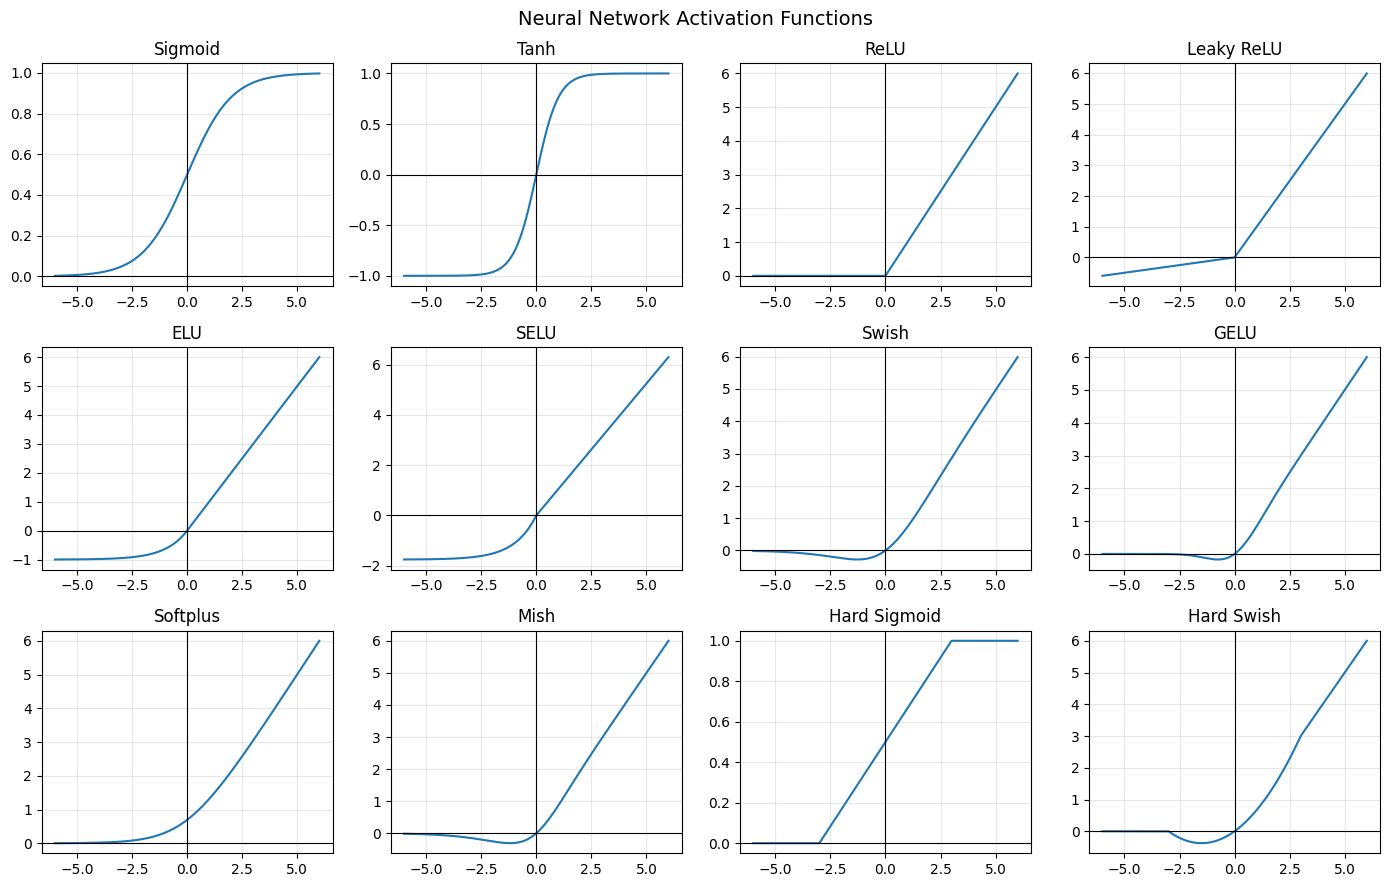

In [124]:
x = np.linspace(-6, 6, 500)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, alpha * x)


def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))


def selu(x):
    lam, alpha = 1.0507, 1.67326
    return lam * np.where(x >= 0, x, alpha * (np.exp(x) - 1))


def swish(x):
    return x * sigmoid(x)


def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x ** 3)))


def softplus(x):
    return np.log1p(np.exp(x))


def mish(x):
    return x * np.tanh(softplus(x))


def hard_sigmoid(x):
    return np.clip((x + 3) / 6, 0, 1)


def hard_swish(x):
    return x * hard_sigmoid(x)


activations = [
    ("Sigmoid", sigmoid(x)),
    ("Tanh", tanh(x)),
    ("ReLU", relu(x)),
    ("Leaky ReLU", leaky_relu(x)),
    ("ELU", elu(x)),
    ("SELU", selu(x)),
    ("Swish", swish(x)),
    ("GELU", gelu(x)),
    ("Softplus", softplus(x)),
    ("Mish", mish(x)),
    ("Hard Sigmoid", hard_sigmoid(x)),
    ("Hard Swish", hard_swish(x)),
]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Neural Network Activation Functions", fontsize=14)

for ax, (name, y_vals) in zip(axes.flat, activations):
    ax.plot(x, y_vals)
    ax.set_title(name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Vanishing Gradients

As training progresses, gradients tend to shrink as they propagate toward the lower layers. When this happens, gradient descent barely updates the weights in those layers, preventing the network from learning effectively. This phenomenon is known as the vanishing‑gradient problem.

[9] identifies two primary causes: the sigmoid activation function and the N(1, 0) weight initialization. Below is a short demo showing why sigmoid can be problematic — its derivative is often a small number, so gradients reaching layers near the input shrink to near-zero and those neurons effectively stop learning.


**Sigmoid**

Remember, $z$ is the weighed sum of the inputs (usually a vector with shape (batch_size,1), but here we consider a single training example).

$$
\frac{\partial \sigma(z)}{\partial z} = \sigma(z)(1 - \sigma(z))
$$

When $z$ is large, $\sigma(z) \to 1$, so the derivative $\to 0$. Concretely:

$$
z = 0: \quad \sigma(0)(1 - \sigma(0)) = 0.5 \times 0.5 = 0.25
$$
$$
z = 3: \quad \sigma(3)(1 - \sigma(3)) = 0.952 \times 0.048 = 0.046
$$
$$
z = 5: \quad \sigma(5)(1 - \sigma(5)) = 0.993 \times 0.007 = 0.007
$$
$$
z = 10: \quad \sigma(10)(1 - \sigma(10)) = 0.9999 \times 0.0001 = 0.0001
$$

The derivative shrinks by a factor of 2500× just going from $z=0$ to $z=10$.



## Weight Initialization

It makes sense to hold off on a deep dive for now. While weight initialization is certainly a critical practical step, it doesn't carry the same theoretical weight or complexity as backprop. So far, I noticed that in the manual implementation in [5] the params were set to a random value between 0 and 1.

I paste an AI-generated explanation (that i edited) at this point, can explore more in the future.

---

Weight initialization is about more than just battling vanishing gradients; it is fundamentally about symmetry breaking and maintaining a stable flow of information through the network.

**Breaking the Symmetry**

If you initialize all your weights to the same value, such as zero, every neuron in a hidden layer will perform the exact same calculation. They will have the same output, receive the same gradient during backpropagation, and update to the same new value. In this scenario, your entire layer effectively behaves like a single neuron, and you lose the expressive power of the network. Random initialization ensures neurons start out differently so they can learn different features.

**Managing Signal Variance**

To keep the network learning efficiently, you want the variance of the inputs to be roughly equal to the variance of the outputs across every layer. If the weights are too small, the signal shrinks (vanishing). If they are too large, the signal grows exponentially (exploding). Weight initialization techniques use mathematical formulas to find a stable middle ground based on the number of inputs and outputs of a layer.

**The Main Techniques**

The specific initialization you choose usually depends on your activation function. Xavier (Glorot) initialization is best used with Sigmoid or Tanh functions because it keeps variance stable for functions centered at zero. He (Kaiming) initialization is designed for ReLU or Leaky ReLU; since ReLU turns negative values to zero, this method compensates by doubling the weight variance.

**Why it Matters for Convergence**

Beyond preventing gradient issues, good initialization speeds up training by starting the optimizer closer to a functional solution. It also prevents saturation in functions like Sigmoid, where large weights can cause the output to get stuck in flat regions where the gradient is almost zero, effectively killing the learning process immediately.


## Demo: Vanishing Gradients

I generated some code with Claude to showcase how gradients can become too small and how ReLU and Glorot initialization prevent the issue.

The neural net architecture has the shape 20-64(x8)-1, with 2000 training examples, all data is simulated and not actual dataset:

<img src="images/09.png" style="width: 600px;">



**Short overview**

- `build_model()` creates the model with its layers
- `gradient_norms()` calculates the L2 norm of the matrix of weights in each layer. It does this by monitoring all weights using `GradientTape`.

**Why L2 norm?**

The goal is to get a single number per layer that answers: "how much is the loss trying to change the weights in this layer?" You need some way to aggregate thousands of gradient values into one summary statistic. The L2 norm is the natural choice because:

1. It captures overall magnitude — it tells you the "total size" of the gradient vector in that layer. If gradients are vanishing, all individual values shrink, and the L2 norm shrinks proportionally.

2. It doesn't cancel out signs — unlike a simple sum (where positive and negative gradients could cancel), L2 squares each value first, so every gradient contributes positively.

3. It's sensitive to large outliers — if even a few gradients are large, the norm reflects that; this is useful because a few large gradients can still drive learning.

In [125]:
# Toy binary classification: 2000 samples, 20 features
n_features = 20
X_vg = np.random.randn(2000, n_features).astype(np.float32)
y_vg = (np.sum(X_vg[:, :4], axis=1) > 0).astype(np.float32)

N_LAYERS = 8  # deep enough to make vanishing clearly visible
N_UNITS = 64


def build_model(activation, initializer):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(n_features,)))
    for i in range(N_LAYERS):
        model.add(keras.layers.Dense(
            N_UNITS,
            activation=activation,
            kernel_initializer=initializer,
            bias_initializer="zeros",
            name=f"h{i + 1}",
        ))
    model.add(keras.layers.Dense(1, activation="sigmoid", name="output"))
    return model


def gradient_norms(model, X_batch, y_batch):
    """L2 norm of weight gradients for each Dense kernel, input→output order."""
    X_t = tf.constant(X_batch)  # convert NumPy → TF tensor
    y_t = tf.constant(y_batch[:, None])  # reshape (m,) → (m, 1) to match model output

    with tf.GradientTape() as tape:  # all operations on all tf.Variables are tracked
        preds = model(X_t, training=True)  # forward pass — recorded on the tape
        loss = tf.reduce_mean(keras.losses.binary_crossentropy(y_t, preds))  # scalar loss (required by .gradient)

    # select only weights and don't use the biases. 'kernel' is an alias for weights 
    weights = [var for var in model.trainable_variables if "kernel" in var.name]

    # backprop happens here!
    grads = tape.gradient(loss, weights)

    return [
        float(tf.norm(g))  # L2 norm collapses the whole weight matrix to one scalar
        for g in grads
    ]


# Use only a mini-batch, used to calculate gradient norms
X_b = tf.constant(X_vg[:512])
y_b = tf.constant(y_vg[:512])

To better understand I debuged and took notes in draw.io (see the *.drawio file in the project).

<img src="images/07.png" style="width: 600px;">
<img src="images/10.png" style="width: 600px;">


We now plot the total change of the gradients i.e. the L2 norm of the weight gradient matrixes.

The left plot is the bad case - sigmoid and N(1,0) initialization. The L2 norm decreases as we go closer to the input layer.

On the right is the better case - ReLU adn Glorot, and the L2 norms for all layers are more equal.

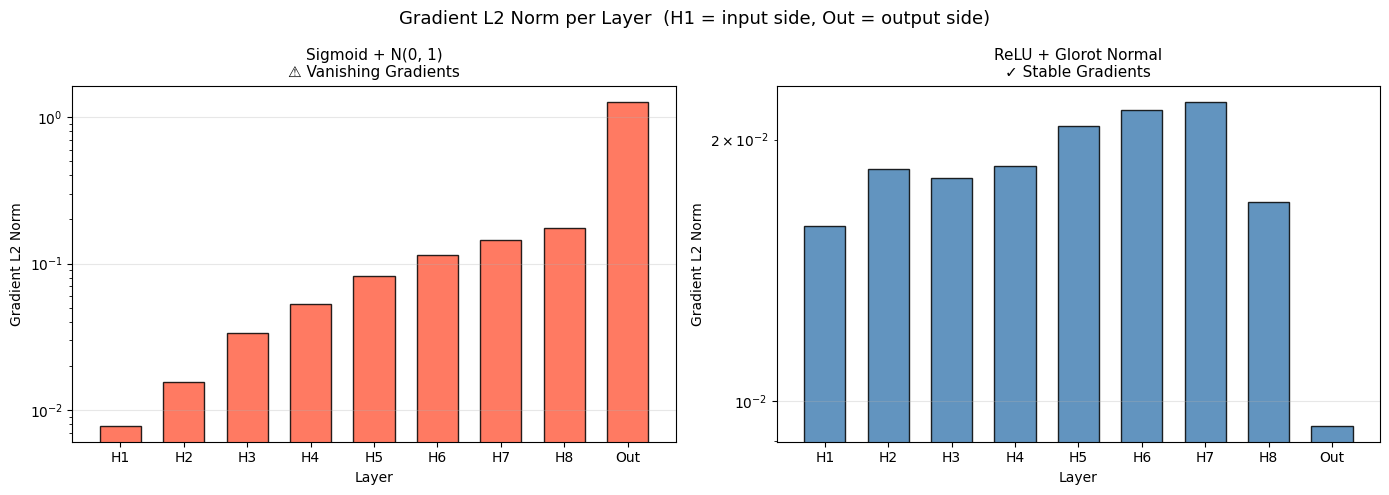

Sigmoid + N(0,1) gradient norms (input → output):
  H1: 7.85e-03
  H2: 1.55e-02
  H3: 3.35e-02
  H4: 5.28e-02
  H5: 8.27e-02
  H6: 1.14e-01
  H7: 1.44e-01
  H8: 1.74e-01
  Out: 1.27e+00

ReLU + Glorot gradient norms (input → output):
  H1: 1.59e-02
  H2: 1.85e-02
  H3: 1.80e-02
  H4: 1.87e-02
  H5: 2.07e-02
  H6: 2.16e-02
  H7: 2.21e-02
  H8: 1.69e-02
  Out: 9.37e-03


In [126]:
# ── Bad: sigmoid + N(0, 1) ─────────────────────────────────────────────────────
# Large initial weights → large pre-activations → sigmoid saturation → σ'(z) ≈ 0
# Each layer multiplies the gradient by ≤ 0.25, so deeper layers starve.
bad_init = keras.initializers.RandomNormal(mean=0.0, stddev=1.0, seed=1)
model_bad = build_model("sigmoid", bad_init)
norms_bad = gradient_norms(model_bad, X_b, y_b)

# ── Good: ReLU + Glorot Normal ─────────────────────────────────────────────────
# Glorot scales σ = sqrt(2 / (fan_in + fan_out)) → preserves activation variance.
# ReLU derivative is 1 for z > 0, so gradients flow without shrinking.
good_init = keras.initializers.GlorotNormal(seed=1)
model_good = build_model("relu", good_init)
norms_good = gradient_norms(model_good, X_b, y_b)

# ── Plot ───────────────────────────────────────────────────────────────────────
layer_labels = [f"H{i}" for i in range(1, N_LAYERS + 1)] + ["Out"]
x = list(range(1, len(layer_labels) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Gradient L2 Norm per Layer  (H1 = input side, Out = output side)",
    fontsize=13,
)

for ax, norms, color, title in [
    (axes[0], norms_bad, "tomato", "Sigmoid + N(0, 1)\n⚠ Vanishing Gradients"),
    (axes[1], norms_good, "steelblue", "ReLU + Glorot Normal\n✓ Stable Gradients"),
]:
    ax.bar(x, norms, color=color, edgecolor="black", alpha=0.85, width=0.65)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(layer_labels)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Gradient L2 Norm")
    ax.set_yscale("log")  # log scale makes the decay visible
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Sigmoid + N(0,1) gradient norms (input → output):")
for lbl, n in zip(layer_labels, norms_bad):
    print(f"  {lbl}: {n:.2e}")

print("\nReLU + Glorot gradient norms (input → output):")
for lbl, n in zip(layer_labels, norms_good):
    print(f"  {lbl}: {n:.2e}")

Also:
- loss drops faster for the good case
- accuracy on validation set is much better, so the improved model is more capable overall (more capacity and generalizes better)

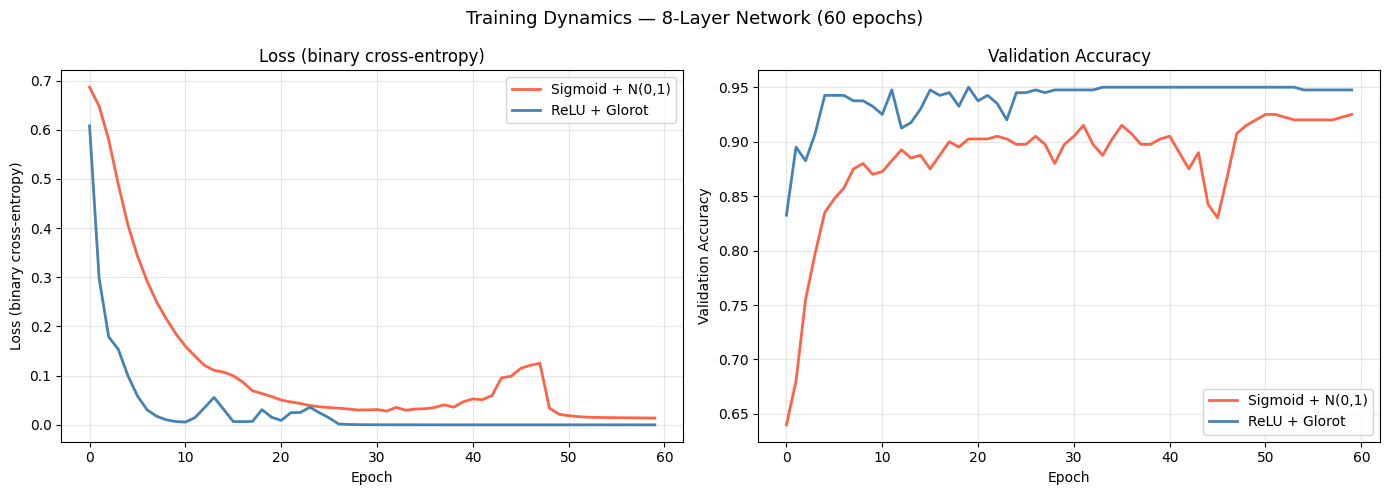

In [106]:
model_bad_t = build_model("sigmoid", keras.initializers.RandomNormal(0.0, 1.0, seed=1))
model_good_t = build_model("relu", keras.initializers.GlorotNormal(seed=1))

for m in [model_bad_t, model_good_t]:
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

# Do this once, right after generating X_vg / y_vg, while np seed is fresh
split = int(0.8 * len(X_vg))
X_train, X_val = X_vg[:split], X_vg[split:]
y_train, y_val = y_vg[:split], y_vg[split:]

# fit a model with all training examples (X_vg with 2000 instead of X_b with 512)
hist_bad = model_bad_t.fit(
    X_train, y_train, epochs=60, batch_size=64,
    validation_data=(X_val, y_val), verbose=0
)
hist_good = model_good_t.fit(
    X_train, y_train, epochs=60, batch_size=64,
    validation_data=(X_val, y_val), verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Dynamics — 8-Layer Network (60 epochs)", fontsize=13)

for ax, bad_key, good_key, ylabel in [
    (axes[0], "loss", "loss", "Loss (binary cross-entropy)"),
    (axes[1], "val_accuracy", "val_accuracy", "Validation Accuracy"),
]:
    ax.plot(hist_bad.history[bad_key], color="tomato", lw=2, label="Sigmoid + N(0,1)")
    ax.plot(hist_good.history[good_key], color="steelblue", lw=2, label="ReLU + Glorot")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## References

[1] Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O’Reilly Media.

[2] Raschka, S. (2022). *Machine learning with PyTorch and Scikit-Learn*. Packt Publishing.

[3] 3Blue1Brown (accessed 2026-03-06) *Neural networks*. https://www.3blue1brown.com/topics/neural-networks

[4] Baydin, A. G., & Pearlmutter, B. A. (2014). Automatic differentiation of algorithms for machine learning. arXiv preprint arXiv:1404.7456. https://arxiv.org/abs/1404.7456

[5] Raschka, S. (accessed 2026-03-08) (Version main) [Computer software]. GitHub. https://github.com/rasbt/machine-learning-book/tree/main/ch11

[6] OpenML. (n.d.). Blood Transfusion Service Center (Version 1) [Data set]. OpenML. https://www.openml.org/search?type=data&sort=runs&id=1464&status=active

[7] Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018). Automatic differentiation in machine learning: A survey [Preprint]. arXiv. https://arxiv.org/pdf/1502.05767

[8] ageron/handson-ml3 (accessed 2026-03-14) (Version main) [Computer software]. GitHub. https://github.com/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb

[9] Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In Proceedings of the Thirteenth International Conference on Artificial Intelligence and Statistics (AISTATS 2010) (Vol. 9, pp. 249–256). Proceedings of Machine Learning Research. https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf